# Notebook 02 — Data Preparation

This notebook:
1. Creates a fixed sequence-level train/val split (never reshuffle!)
2. Extracts all detection crops from the training sequences
3. Builds positive/negative ReID pairs for classifier training
4. Saves everything to disk for use in both pipelines

In [3]:
import os, json, random, cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# Load config from notebook 01
with open(os.path.join(
    r'D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone',
    'VisDrone_outputs', 'config.json')) as f:
    cfg = json.load(f)

TRAIN_DIR   = cfg['TRAIN_DIR']
print(f'TRAIN_DIR   : {TRAIN_DIR}')
VAL_DIR     = cfg['VAL_DIR']
print(f'VAL_DIR     : {VAL_DIR}')
OUTPUT_DIR  = cfg['OUTPUT_DIR']
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')
VALID_CLASSES = set(cfg['VALID_CLASSES'])
print(f'VALID_CLASSES : {VALID_CLASSES}')
TRAIN_SEQS  = cfg['TRAIN_SEQS']
print(f'TRAIN_SEQS  : {TRAIN_SEQS}')
VAL_SEQS    = cfg['VAL_SEQS']
print(f'VAL_SEQS    : {VAL_SEQS}')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Config loaded!')
print(f'Train sequences: {len(TRAIN_SEQS)}')

TRAIN_DIR   : D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\VisDrone_dataset\VisDrone2019-MOT-train
VAL_DIR     : D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\data\VisDrone_dataset\VisDrone2019-MOT-val
OUTPUT_DIR  : D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs
VALID_CLASSES : {1, 2, 4, 5, 6, 9}
TRAIN_SEQS  : ['uav0000013_00000_v', 'uav0000013_01073_v', 'uav0000013_01392_v', 'uav0000020_00406_v', 'uav0000071_03240_v', 'uav0000072_04488_v', 'uav0000072_05448_v', 'uav0000072_06432_v', 'uav0000076_00720_v', 'uav0000079_00480_v', 'uav0000084_00000_v', 'uav0000099_02109_v', 'uav0000124_00944_v', 'uav0000126_00001_v', 'uav0000138_00000_v', 'uav0000140_01590_v', 'uav0000143_02250_v', 'uav0000145_00000_v', 'uav0000150_02310_v', 'uav0000218_00001_v', 'uav0000222_03150_v', 'uav0000239_03720_v', 'uav0000239_12336_v', 'uav0000243_00001_v', 'uav0000244_01440_v', 'uav0000248_00001_v', 'uav0000263_03289_v', 'uav0000264_02760_v', 'uav0000266_03598_v', 'uav0000266_04830_v',

## Cell 1 — Sequence-Level Train/Val Split

### Why Sequence-Level?
We must NEVER split frames of the same sequence across train/val sets.
If frames 1-500 of sequence A are in train and frames 501-1000 are in val,
the model can memorise identity appearances — this is **data leakage**.

**Split protocol:**
- Sort sequences by name (deterministic)
- Take first 70% as sub-train (for ReID pair building)
- Take last 30% as sub-val (for internal evaluation)
- The official VisDrone val set (7 sequences) is used for final tracking evaluation

In [4]:
def create_sequence_split(all_seqs, train_ratio=0.70, seed=42):
    """
    Create a fixed sequence-level split.

    IMPORTANT: We sort by name first for determinism,
    then shuffle with a fixed seed — so the split is always the same.
    This file is saved and NEVER reshuffled between experiments.

    Args:
        all_seqs   : list of all sequence names
        train_ratio: fraction to use for ReID training (default 70%)
        seed       : random seed for reproducibility

    Returns:
        (train_seqs, val_seqs) tuple of lists
    """
    seqs = sorted(all_seqs)  # Sort first for determinism
    random.Random(seed).shuffle(seqs)  # Shuffle with fixed seed

    split_idx  = int(len(seqs) * train_ratio)
    train_seqs = seqs[:split_idx]
    val_seqs   = seqs[split_idx:]
    return train_seqs, val_seqs


# Create the split
reid_train_seqs, reid_val_seqs = create_sequence_split(TRAIN_SEQS, 0.70)

print(f'ReID training sequences  : {len(reid_train_seqs)}')
print(f'ReID validation sequences: {len(reid_val_seqs)}')

# Save split files — these are FIXED and never change
splits_dir = os.path.join(OUTPUT_DIR, 'splits')

with open(os.path.join(splits_dir, 'reid_train_sequences.txt'), 'w') as f:
    f.write('\n'.join(reid_train_seqs))

with open(os.path.join(splits_dir, 'reid_val_sequences.txt'), 'w') as f:
    f.write('\n'.join(reid_val_seqs))

print(f'\n✅ Split files saved to: {splits_dir}')
print('\nFirst 5 ReID train seqs:', reid_train_seqs[:5])
print('First 5 ReID val seqs  :', reid_val_seqs[:5])

ReID training sequences  : 39
ReID validation sequences: 17

✅ Split files saved to: D:\MTech\Sem-2\IT585-Advanced_ML\AML-project\VisDrone\VisDrone_outputs\splits

First 5 ReID train seqs: ['uav0000270_00001_v', 'uav0000243_00001_v', 'uav0000352_05980_v', 'uav0000099_02109_v', 'uav0000143_02250_v']
First 5 ReID val seqs  : ['uav0000361_02323_v', 'uav0000013_01392_v', 'uav0000264_02760_v', 'uav0000289_06922_v', 'uav0000072_04488_v']


## Cell 2 — Extract Detection Crops from Training Sequences

For each valid detection in each training frame, we:
1. Read the frame image
2. Crop the bounding box region (clipped to image bounds)
3. Resize to a standard size (64×128 — standard person crop size)
4. Store along with metadata (sequence, frame_id, target_id, class)

**Crop size**: 64×128 pixels (width × height) — portrait aspect ratio
matching typical pedestrian proportions

In [5]:
def read_visdrone_annotation(anno_path, valid_classes=None):
    """Read and filter a VisDrone annotation file."""
    cols = ['frame_id', 'target_id', 'x', 'y', 'w', 'h',
            'score', 'class_id', 'truncation', 'occlusion']
    df = pd.read_csv(anno_path, header=None, names=cols)
    df = df[df['score'] == 1]
    df = df[df['target_id'] > 0]
    if valid_classes:
        df = df[df['class_id'].isin(valid_classes)]
    df = df[(df['w'] > 0) & (df['h'] > 0)]
    return df.reset_index(drop=True)


def extract_crops_from_sequence(split_dir, seq_name, valid_classes,
                                 crop_size=(64, 128), min_crop_area=400):
    """
    Extract all person crops from a sequence.

    Args:
        split_dir    : TRAIN_DIR or VAL_DIR
        seq_name     : sequence name string
        valid_classes: set of class IDs to keep
        crop_size    : (width, height) to resize each crop to
        min_crop_area: skip crops smaller than this (in pixels²)

    Returns:
        list of dicts, each containing:
            - 'crop': numpy array (H, W, 3) in BGR
            - 'seq', 'frame_id', 'target_id', 'class_id'
            - 'x', 'y', 'w', 'h' (original bbox)
    """
    anno_path = os.path.join(split_dir, 'annotations', seq_name + '.txt')
    seq_dir   = os.path.join(split_dir, 'sequences', seq_name)
    df = read_visdrone_annotation(anno_path, valid_classes)

    crops = []
    for fid, frame_df in df.groupby('frame_id'):
        img_path = os.path.join(seq_dir, f'{fid:07d}.jpg')
        if not os.path.exists(img_path):
            continue
        img = cv2.imread(img_path)  # BGR format
        if img is None:
            continue
        H_img, W_img = img.shape[:2]

        for _, row in frame_df.iterrows():
            # Clamp bounding box to image dimensions
            x1 = max(0, int(row['x']))
            y1 = max(0, int(row['y']))
            x2 = min(W_img, int(row['x'] + row['w']))
            y2 = min(H_img, int(row['y'] + row['h']))

            if (x2 - x1) * (y2 - y1) < min_crop_area:
                continue  # Too small to be useful

            crop = img[y1:y2, x1:x2]
            crop = cv2.resize(crop, crop_size)
            crops.append({
                'crop'     : crop,
                'seq'      : seq_name,
                'frame_id' : int(row['frame_id']),
                'target_id': int(row['target_id']),
                'class_id' : int(row['class_id']),
                'x': x1, 'y': y1, 'w': x2-x1, 'h': y2-y1
            })
    return crops


# Extract crops from all ReID training sequences
print('Extracting crops from ReID training sequences...')
print('(This may take 5-10 minutes)')

all_crops = []
for seq in tqdm(reid_train_seqs, desc='Sequences'):
    seq_crops = extract_crops_from_sequence(TRAIN_DIR, seq, VALID_CLASSES)
    all_crops.extend(seq_crops)

print(f'\n✅ Total crops extracted: {len(all_crops):,}')

Extracting crops from ReID training sequences...
(This may take 5-10 minutes)


Sequences: 100%|██████████| 39/39 [09:57<00:00, 15.32s/it]


✅ Total crops extracted: 684,508


In [6]:
# Stats by class
from collections import Counter
class_counts = Counter(c['class_id'] for c in all_crops)
print('\nCrops by class:')
CLASS_NAMES = cfg['CLASS_NAMES']
for cid, cnt in sorted(class_counts.items()):
    print(f'  {CLASS_NAMES[str(cid)]:20s}: {cnt:,}')


Crops by class:
  pedestrian          : 162,909
  people              : 64,612
  car                 : 390,817
  van                 : 35,487
  truck               : 23,112
  bus                 : 7,571


## Cell 3 — Build ReID Pairs for XGBoost Training

### Pair Construction Strategy

**Positive pair** (label = 1): Two crops of the **same target_id** from **different frames**
(ensures temporal gap, so appearance can vary slightly)

**Negative pair** (label = 0): Two crops of **different target_ids** from the **same sequence**
and nearby frames (hard negatives — similar scene conditions)

**Balancing**: 1:2 positive-to-negative ratio

### Why These Pairs?
- Positives with temporal gap teach the model appearance **invariance over time**
- Hard negatives (same sequence) teach the model to distinguish **similar-looking people in the same scene**

In [7]:
def build_reid_pairs(crops, pos_per_id=5, neg_ratio=2, seed=42):
    """
    Build positive and negative crop pairs for ReID classifier training.

    Positive pair  (label=1): same target_id, different frames
    Negative pair  (label=0): different target_id, same sequence

    Args:
        crops      : list of crop dicts from extract_crops_from_sequence
        pos_per_id : max positive pairs to generate per identity
        neg_ratio  : number of negatives per positive
        seed       : random seed

    Returns:
        pairs: list of (crop_a, crop_b, label) tuples
    """
    rng = random.Random(seed)

    # Group crops by (sequence, target_id)
    id_to_crops = defaultdict(list)
    seq_to_crops = defaultdict(list)
    for i, c in enumerate(crops):
        key = (c['seq'], c['target_id'])
        id_to_crops[key].append(i)
        seq_to_crops[c['seq']].append(i)

    positive_pairs = []
    # ── Build positive pairs ──────────────────────────────────────
    for (seq, tid), indices in id_to_crops.items():
        if len(indices) < 2:
            continue
        # Pick pairs with different frame_ids
        attempts = 0
        generated = 0
        while generated < pos_per_id and attempts < 50:
            a, b = rng.sample(indices, 2)
            if crops[a]['frame_id'] != crops[b]['frame_id']:
                positive_pairs.append((a, b, 1))
                generated += 1
            attempts += 1

    # ── Build negative pairs ──────────────────────────────────────
    n_neg = len(positive_pairs) * neg_ratio
    negative_pairs = []
    all_seq_names = list(seq_to_crops.keys())
    attempts = 0
    while len(negative_pairs) < n_neg and attempts < n_neg * 10:
        seq = rng.choice(all_seq_names)
        seq_indices = seq_to_crops[seq]
        if len(seq_indices) < 2:
            attempts += 1
            continue
        a, b = rng.sample(seq_indices, 2)
        if crops[a]['target_id'] != crops[b]['target_id']:
            negative_pairs.append((a, b, 0))
        attempts += 1

    all_pairs = positive_pairs + negative_pairs
    rng.shuffle(all_pairs)
    print(f'Positive pairs: {len(positive_pairs):,}')
    print(f'Negative pairs: {len(negative_pairs):,}')
    print(f'Total pairs   : {len(all_pairs):,}')
    return all_pairs


print('Building ReID pairs...')
reid_pairs = build_reid_pairs(all_crops, pos_per_id=5, neg_ratio=2)

# Save pair indices and labels (not the crops themselves — too large)
import pickle
pair_data = {
    'pairs'    : reid_pairs,   # list of (idx_a, idx_b, label)
    'n_crops'  : len(all_crops),
    'n_pairs'  : len(reid_pairs)
}
with open(os.path.join(OUTPUT_DIR, 'features', 'reid_pair_indices.pkl'), 'wb') as f:
    pickle.dump(pair_data, f)

print('\n✅ Pair indices saved!')
print('✅ Ready for Notebook 03: Classical Pipeline')

Building ReID pairs...
Positive pairs: 20,640
Negative pairs: 41,280
Total pairs   : 61,920

✅ Pair indices saved!
✅ Ready for Notebook 03: Classical Pipeline


## Cell 4 — Visualise Sample Positive and Negative Pairs

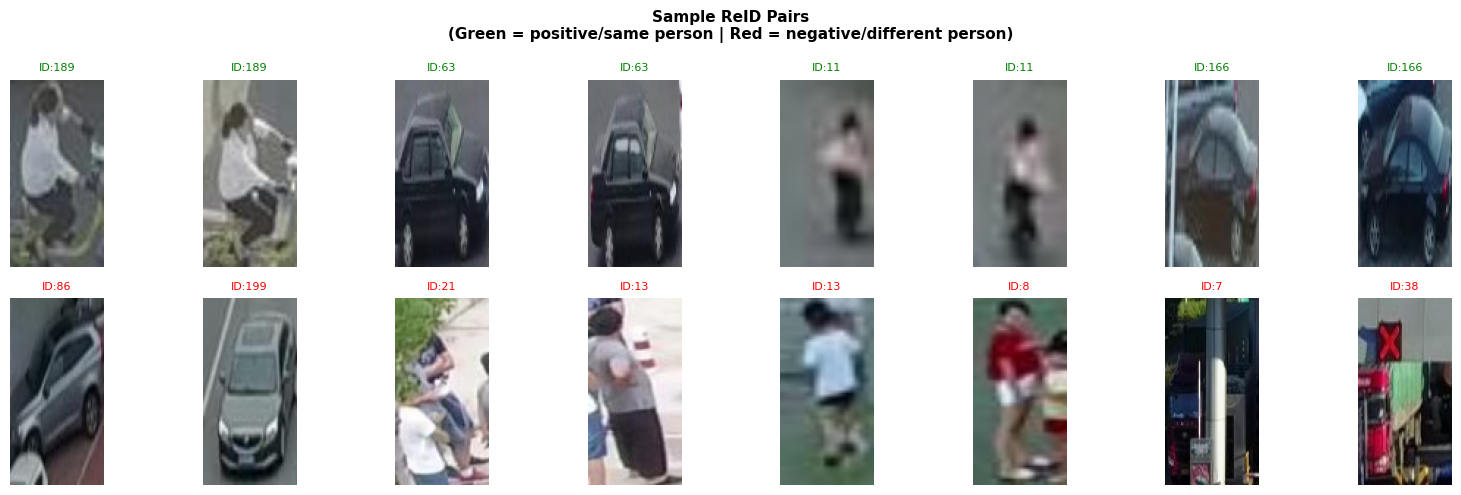

In [9]:
import matplotlib.pyplot as plt

def show_sample_pairs(crops, pairs, n_show=4):
    """Visualise sample positive and negative pairs side by side."""
    pos_pairs = [(a, b, l) for a, b, l in pairs if l == 1][:n_show]
    neg_pairs = [(a, b, l) for a, b, l in pairs if l == 0][:n_show]

    fig, axes = plt.subplots(2, n_show * 2, figsize=(n_show * 4, 5))
    fig.suptitle('Sample ReID Pairs\n(Green = positive/same person | Red = negative/different person)',
                 fontsize=11, fontweight='bold')

    for col, (a, b, label) in enumerate(pos_pairs):
        for row_offset, idx in enumerate([a, b]):
            ax = axes[0][col*2 + row_offset]
            img = cv2.cvtColor(crops[idx]['crop'], cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"ID:{crops[idx]['target_id']}", fontsize=8, color='green')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor('green'); spine.set_linewidth(2)

    for col, (a, b, label) in enumerate(neg_pairs):
        for row_offset, idx in enumerate([a, b]):
            ax = axes[1][col*2 + row_offset]
            img = cv2.cvtColor(crops[idx]['crop'], cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"ID:{crops[idx]['target_id']}", fontsize=8, color='red')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor('red'); spine.set_linewidth(2)

    axes[0][0].set_ylabel('Positive\n(same person)', color='green', fontsize=9)
    axes[1][0].set_ylabel('Negative\n(diff person)', color='red', fontsize=9)
    plt.tight_layout()
    plt.show()

show_sample_pairs(all_crops, reid_pairs)